In [4]:
import pandas as pd
import numpy as np 
import datetime as dt 

import warnings 
warnings.filterwarnings("ignore")

In [5]:
df=pd.read_csv("unemployment in india.csv")

In [6]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [7]:
df.tail()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.isnull().sum()


Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [9]:
cleaned_df= df.dropna()

In [10]:
print((cleaned_df.isnull().sum()/len(cleaned_df))*100)

Region                                      0.0
 Date                                       0.0
 Frequency                                  0.0
 Estimated Unemployment Rate (%)            0.0
 Estimated Employed                         0.0
 Estimated Labour Participation Rate (%)    0.0
Area                                        0.0
dtype: float64


In [11]:
cleaned_df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [12]:
cleaned_df.columns=['state','date','frequency','estimated unemployement rate','estimated employed','estimated labour participation rate','region']

In [13]:
cleaned_df.columns

Index(['state', 'date', 'frequency', 'estimated unemployement rate',
       'estimated employed', 'estimated labour participation rate', 'region'],
      dtype='str')

In [14]:
cleaned_df.head()

,state,date,frequency,estimated unemployement rate,estimated employed,estimated labour participation rate,region
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [15]:
cleaned_df.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   state                                740 non-null    str    
 1   date                                 740 non-null    str    
 2   frequency                            740 non-null    str    
 3   estimated unemployement rate         740 non-null    float64
 4   estimated employed                   740 non-null    float64
 5   estimated labour participation rate  740 non-null    float64
 6   region                               740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 46.2 KB


In [17]:
cleaned_df["date"]

0       31-05-2019
1       30-06-2019
2       31-07-2019
3       31-08-2019
4       30-09-2019
          ...     
749     29-02-2020
750     31-03-2020
751     30-04-2020
752     31-05-2020
753     30-06-2020
Name: date, Length: 740, dtype: str

In [20]:
cleaned_df["Date"] = pd.to_datetime(cleaned_df["date"], dayfirst = True)

In [21]:
cleaned_df.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 8 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   state                                740 non-null    str           
 1   date                                 740 non-null    str           
 2   frequency                            740 non-null    str           
 3   estimated unemployement rate         740 non-null    float64       
 4   estimated employed                   740 non-null    float64       
 5   estimated labour participation rate  740 non-null    float64       
 6   region                               740 non-null    str           
 7   Date                                 740 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 52.0 KB


In [22]:
cleaned_df["Month"] = cleaned_df["Date"].dt.month

In [23]:
cleaned_df.head()

,state,date,frequency,estimated unemployement rate,estimated employed,estimated labour participation rate,region,Date,Month
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural,2019-05-31,5
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural,2019-06-30,6
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural,2019-07-31,7
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural,2019-08-31,8
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural,2019-09-30,9


In [25]:
cleaned_df["Frequency"] = cleaned_df["frequency"].astype("category")

In [26]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df_corr = cleaned_df.corr(numeric_only = True)

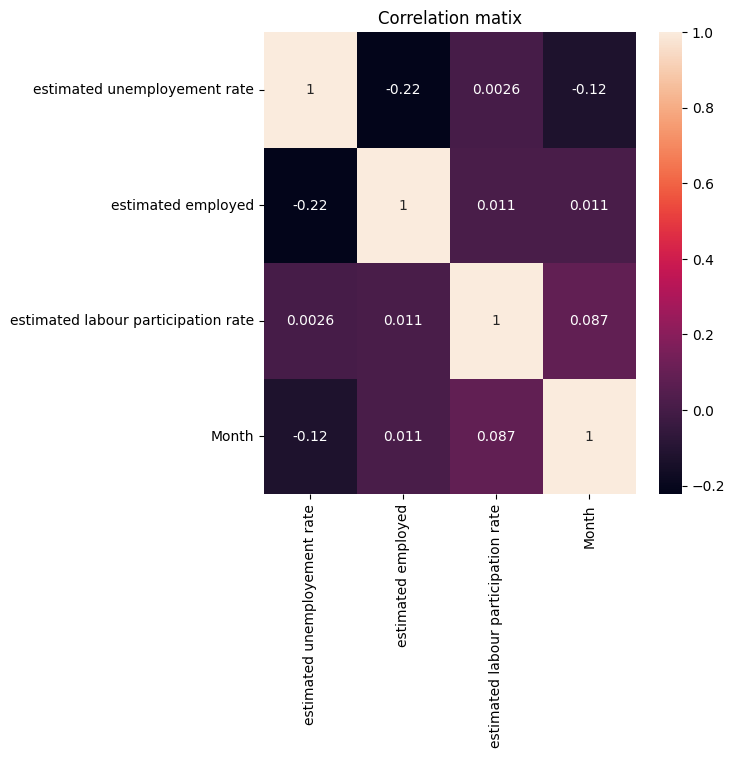

In [35]:
plt.figure(figsize = (6,6))
plt.title("Correlation matix")
sns.heatmap(df_corr , annot = True)
plt.show()

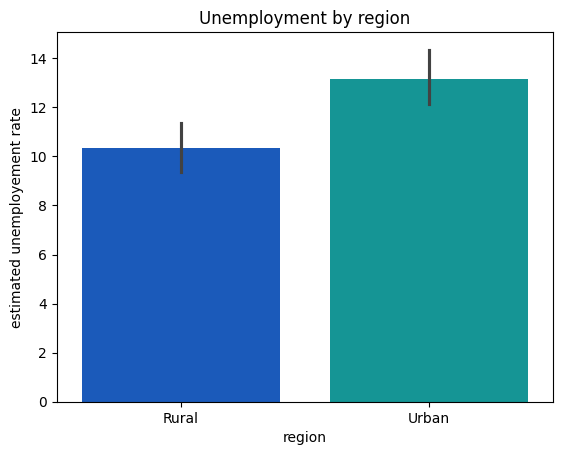

In [38]:
plt.title("Unemployment by region")
sns.barplot(x = "region", y = "estimated unemployement rate" , data = cleaned_df, palette= "winter")
plt.show()

<Axes: xlabel='estimated employed', ylabel='estimated unemployement rate'>

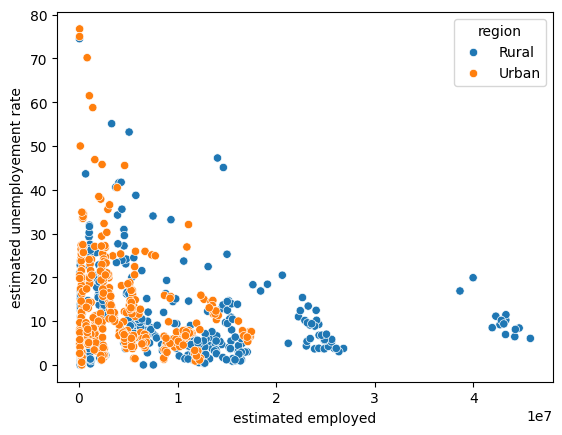

In [42]:
sns.scatterplot(
    x = "estimated employed",
    y = "estimated unemployement rate",
    hue = "region", 
    data = cleaned_df
)

In [46]:
state_data = cleaned_df.groupby("region")["estimated unemployement rate"].mean().sort_values()

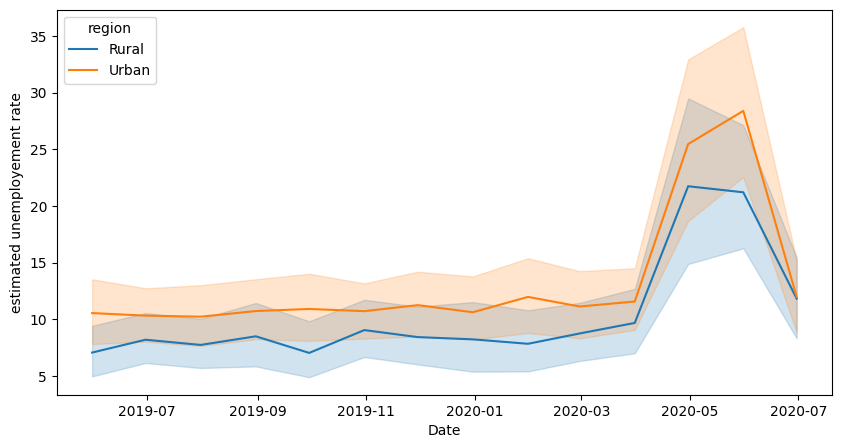

In [50]:
plt.figure(figsize = (10 , 5))
sns.lineplot(
    x = "Date",
    y = "estimated unemployement rate",
    hue = "region",
    data = cleaned_df
)

plt.show()

### Conclusion

1. The unemployment dataset was successfully cleaned and transformed by handling missing values, renaming columns, and converting date fields into a usable format for analysis.

2. Correlation analysis and visualizations helped identify relationships between unemployment rate, employment levels, and labor participation across different regions of India.

3. Regional analysis revealed significant variations in unemployment rates, indicating that some regions experienced higher unemployment challenges than others.

4. The project demonstrates how data analysis and visualization techniques can be used to understand unemployment trends, support decision-making, and provide insights for policymakers and researchers.
